# DefenSync — Machine Learning Analysis

**Project:** DefenSync (CloudSync) — Behavioral Log Intelligence Platform  
**Notebook:** `DefenSync_ML_Analysis.ipynb`  
**Purpose:** Reproduce and document the **exact** hybrid ML pipeline implemented in `backend/services/detection_service.py` using live PostgreSQL data.

> **Note:** This notebook mirrors production logic only. It does **not** introduce new models, features, or synthetic data.

---

### Notebook Structure

| # | Section |
|---|---------|
| 1 | Project Introduction |
| 2 | Load Libraries |
| 3 | Load Live Dataset |
| 4 | Exploratory Data Analysis |
| 5 | Feature Engineering |
| 6 | Isolation Forest |
| 7 | Isolation Forest Visualizations |
| 8 | Random Forest |
| 9 | Operational ML Outputs & Prediction Distribution |
| 10 | Feature Importance |
| 11 | Hybrid Detection Strategy & Pipeline |
| 12 | Integration with DefenSync |
| 13 | Conclusion |
| 14 | Key Findings |


---
## Section 1 — Project Introduction

### Project Name
**DefenSync** — Multi-Server Behavioral Log Intelligence and Security Event Analysis Platform

### Problem Statement
Linux servers generate large volumes of heterogeneous security logs (authentication, sudo, audit). Manual review does not scale. DefenSync collects logs over SSH, normalizes them, assigns rule-based risk scores, and applies **unsupervised (Isolation Forest)** plus **supervised (Random Forest on pseudo-labels)** detection to flag suspicious and malicious behavior.

### Objectives
1. Inspect the live `events` dataset stored by DefenSync  
2. Reproduce the 15-feature matrix from `DetectionService._features()`  
3. Train Isolation Forest with production parameters  
4. Train Random Forest with production parameters and pseudo-labels  
5. Apply the same classification merge logic as `run_detection()`  
6. Visualize results and relate them to `detections` and `alerts` tables  

### Why Machine Learning?
Rule-based risk scoring alone cannot capture multivariate behavioral outliers. Isolation Forest detects anomalies in the 15-dimensional feature space. Random Forest learns patterns aligned with rule-derived suspicious classes.

### Why Behavioral Detection?
Features include session duration, failed login counts, resource telemetry (CPU/RAM/disk/network from SSH collection), risk score, severity, and behavioral flags — reflecting **behavior**, not signatures alone.

### Architecture Diagram

```
Linux Server → SSH (Paramiko) → CollectorService
    → Parser → Normalizer → RiskEngine (rules) → events table
    → DetectionService._load_events(limit=2000)
    → _features() → IsolationForest + RandomForestClassifier
    → detections table → AlertService → alerts table → Dashboard
```

---
## Section 2 — Load Libraries

Libraries used by the DefenSync backend ML stack (`backend/requirements.txt`): NumPy, scikit-learn, SQLAlchemy, python-dotenv.  
Visualization and dataframe utilities (standard for analysis notebooks): pandas, matplotlib, seaborn.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "backend").exists() and (ROOT.parent / "backend").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from IPython.display import display, Markdown
from sqlalchemy import select
from sklearn.ensemble import IsolationForest, RandomForestClassifier

from backend.database.connection import get_engine, get_session
from backend.database.models import SecurityEvent
from backend.services.detection_service import DetectionService

load_dotenv(ROOT / ".env")

# Consistent presentation settings
FIG_W, FIG_H = 12, 6
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.figsize": (FIG_W, FIG_H),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})
print(f"Project root: {ROOT}")


Project root: C:\Users\Lenovo\OneDrive\Desktop\CloudSync


---
## Section 3 — Load Live Dataset

Connect via the project's `get_engine()` (reads `DATABASE_URL` from `.env`).  
Full table scan for EDA; ML training uses the **same 2,000-event window** as `DetectionService._load_events()`.

In [2]:
engine = get_engine()

df_events = pd.read_sql("SELECT * FROM events ORDER BY timestamp DESC", engine)
df_alerts = pd.read_sql("SELECT * FROM alerts", engine)
df_detections = pd.read_sql("SELECT * FROM detections", engine)
df_servers = pd.read_sql("SELECT id, server_name, owner_id, health_status FROM servers", engine)

print("=== events table ===")
print(f"Shape: {df_events.shape}")
print(f"Columns ({len(df_events.columns)}): {list(df_events.columns)}")
print("\nData types:")
print(df_events.dtypes)
print("\nMissing values per column:")
print(df_events.isnull().sum())
print(f"\nDuplicate event_id: {df_events['event_id'].duplicated().sum()}")
print(f"Duplicate hash: {df_events['hash'].duplicated().sum()}")
print("\nFirst 10 records:")
display(df_events.head(10))

=== events table ===
Shape: (17622, 28)
Columns (28): ['id', 'event_id', 'timestamp', 'hostname', 'username', 'source_ip', 'event_type', 'category', 'severity', 'risk_score', 'process', 'message', 'raw_log', 'hash', 'server_id', 'risk_level', 'cpu_usage', 'memory_usage', 'disk_usage', 'login_time', 'logout_time', 'failed_login_count', 'session_duration', 'commands_executed', 'network_connections', 'owner_id', 'command', 'normalized_data']

Data types:
id                             object
event_id                       object
timestamp              datetime64[ns]
hostname                       object
username                       object
source_ip                      object
event_type                     object
category                       object
severity                       object
risk_score                      int64
process                        object
message                        object
raw_log                        object
hash                           object
server_id   

,id,event_id,timestamp,hostname,username,source_ip,event_type,category,severity,risk_score,...,disk_usage,login_time,logout_time,failed_login_count,session_duration,commands_executed,network_connections,owner_id,command,normalized_data
0,5ab77eec-cace-44ff-afe2-e4b9430b35c1,1064d675-7b29-4d1f-bbfb-43eb8d8fc0b7,2026-07-08 13:51:16.418176,web-server-01,None,None,Invalid Action,unknown,critical,95,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,5747dbf9-dd6d-4886-bab5-a3a1c0d13d8f,None,{}
1,3faa2bbe-d7ad-494b-bf39-4c47c62d5958,b93689c6-1fb4-4e14-9944-779fb1c627b1,2026-07-08 13:51:16.418173,db-server,db_admin,10.0.0.50,Successful Login,unknown,low,10,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,5747dbf9-dd6d-4886-bab5-a3a1c0d13d8f,None,{}
2,57a1c432-fe55-4aee-a4b7-c79d49227ad5,ee3db443-1870-47e6-ae32-3eddf1430f2f,2026-07-08 13:51:16.418167,web-server-01,root,127.0.0.1,Sudo Command,unknown,high,85,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,5747dbf9-dd6d-4886-bab5-a3a1c0d13d8f,None,{}
3,565b74a6-2e6c-4017-8a8b-c02facb720fe,aece5308-ad1b-4af1-adf7-87d566ffb3ce,2026-07-08 13:51:16.418126,web-server-01,root,203.0.113.5,Failed Login,unknown,medium,30,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,5747dbf9-dd6d-4886-bab5-a3a1c0d13d8f,None,{}
4,c659d6ef-160c-430b-90e0-30faede863e5,b9c5a857-7c9d-4226-9c4f-fc2e996610e2,2026-07-08 13:51:11.972320,workstation-01,admin,192.168.1.100,Failed Login,unknown,medium,45,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,5747dbf9-dd6d-4886-bab5-a3a1c0d13d8f,None,{}
5,60776f44-c464-423e-b3e4-75b518d5622d,1fbae29e-f618-4093-996c-9f6914aeb761,2026-07-08 00:21:36.053137,New OS,root,None,Successful Login,authentication,high,55,...,28.0,NaT,NaT,NaN,NaN,NaN,10.0,f2903a57-a906-45b8-a848-613b2e4dd8ca,w,"{""source"": ""w"", ""line"": ""root 00..."
6,3c3d7fcf-f6c8-4e61-a428-bfd39ef1243f,dab7332c-704e-4ca8-8a74-af49915bced7,2026-07-08 00:21:36.053137,New OS,root,None,Successful Login,authentication,high,55,...,28.0,NaT,NaT,NaN,NaN,NaN,10.0,f2903a57-a906-45b8-a848-613b2e4dd8ca,w,"{""source"": ""w"", ""line"": ""root pts/0 23..."
7,96de43d0-4342-4d5b-a115-2365f7792fe0,81b5750e-e74e-469c-8d5d-bdac890bf46b,2026-07-08 00:21:36.053137,New OS,centu,None,Successful Login,authentication,low,20,...,28.0,NaT,NaT,NaN,NaN,NaN,10.0,f2903a57-a906-45b8-a848-613b2e4dd8ca,w,"{""source"": ""w"", ""line"": ""centu tty2 23..."
8,d9fbe9f4-685b-473b-b2ee-d6d886b7484f,0b7d32f4-86f8-4252-a817-c3985f71dff0,2026-07-08 00:21:36.053137,New OS,USER,None,Successful Login,authentication,low,20,...,28.0,NaT,NaT,NaN,NaN,NaN,10.0,f2903a57-a906-45b8-a848-613b2e4dd8ca,w,"{""source"": ""w"", ""line"": ""USER TTY L..."
9,f5db63d0-3942-47e5-a392-2753bf366749,e62e8bd3-c8ec-46a9-a32f-72231ecc5485,2026-07-08 00:21:36.053137,New OS,00:21:36,None,Successful Login,authentication,low,20,...,28.0,NaT,NaT,NaN,NaN,NaN,10.0,f2903a57-a906-45b8-a848-613b2e4dd8ca,w,"{""source"": ""w"", ""line"": "" 00:21:36 up 52 min, ..."


In [3]:
summary = {
    "total_events": len(df_events),
    "total_alerts": len(df_alerts),
    "total_detections_stored": len(df_detections),
    "total_servers": len(df_servers),
}
pd.Series(summary, name="count")

total_events               17622
total_alerts                3077
total_detections_stored     9344
total_servers                  2
Name: count, dtype: int64

---
## Section 4 — Exploratory Data Analysis

All charts use **live PostgreSQL data** from the `events` and `alerts` tables.

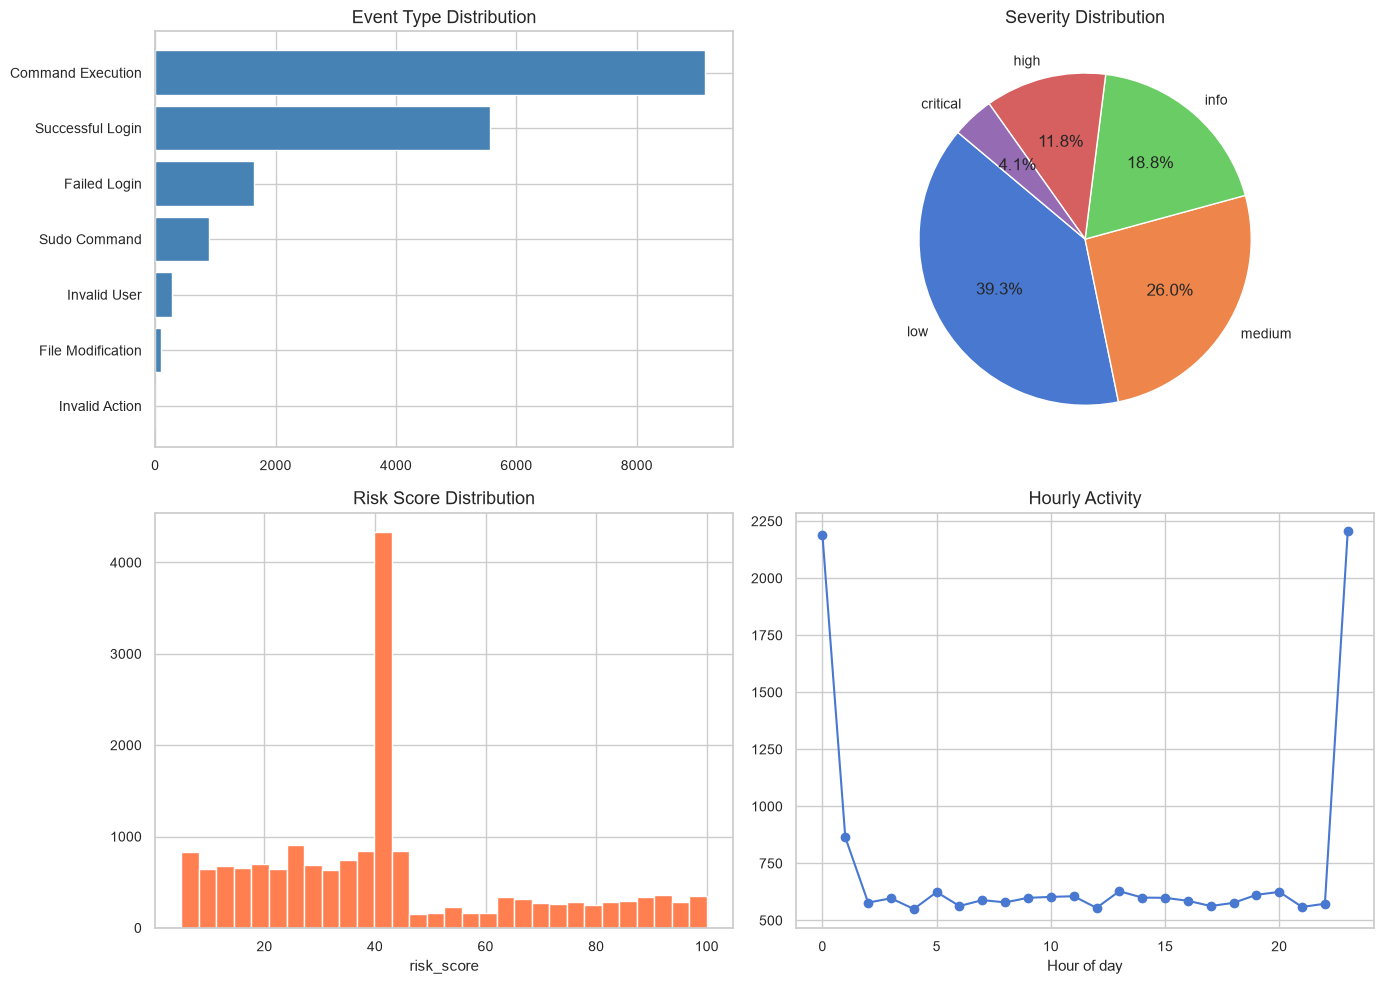

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

etype = df_events["event_type"].value_counts()
axes[0, 0].barh(etype.index, etype.values, color="steelblue")
axes[0, 0].set_title("Event Type Distribution")
axes[0, 0].invert_yaxis()

sev = df_events["severity"].value_counts()
axes[0, 1].pie(sev.values, labels=sev.index, autopct="%1.1f%%", startangle=140)
axes[0, 1].set_title("Severity Distribution")

axes[1, 0].hist(df_events["risk_score"], bins=30, color="coral", edgecolor="white")
axes[1, 0].set_title("Risk Score Distribution")
axes[1, 0].set_xlabel("risk_score")

df_events["hour"] = pd.to_datetime(df_events["timestamp"]).dt.hour
hourly = df_events["hour"].value_counts().sort_index()
axes[1, 1].plot(hourly.index, hourly.values, marker="o")
axes[1, 1].set_title("Hourly Activity")
axes[1, 1].set_xlabel("Hour of day")

plt.tight_layout()
plt.show()

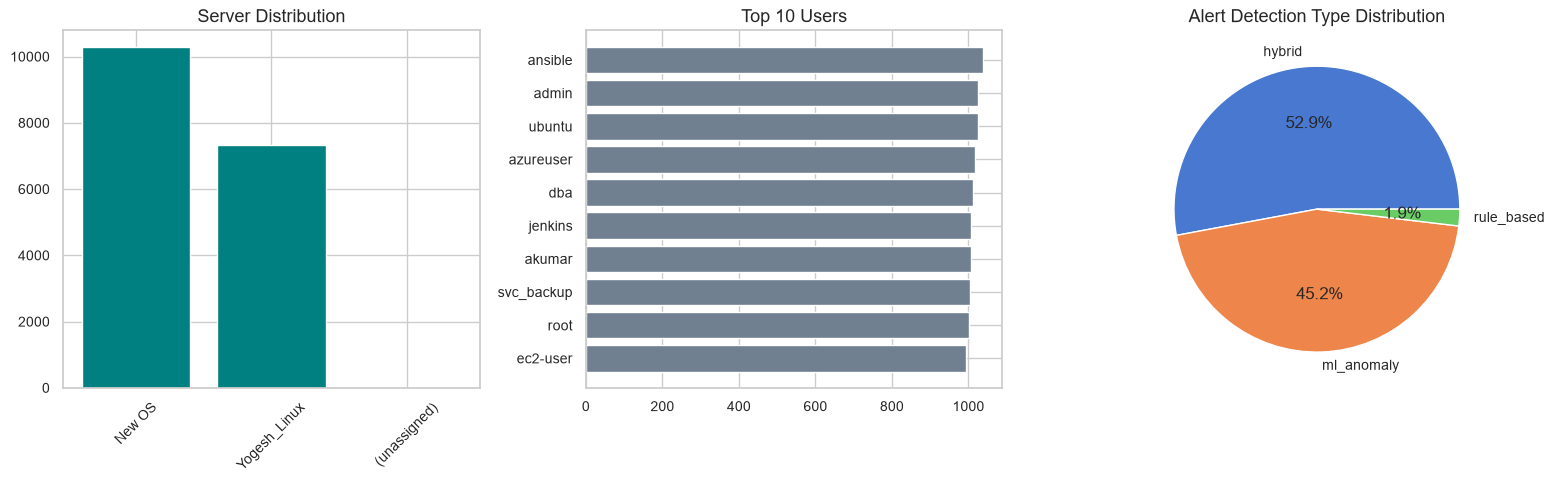

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

srv = df_events.merge(df_servers, left_on="server_id", right_on="id", how="left")
srv_counts = srv["server_name"].fillna("(unassigned)").value_counts()
axes[0].bar(srv_counts.index, srv_counts.values, color="teal")
axes[0].set_title("Server Distribution")
axes[0].tick_params(axis="x", rotation=45)

users = df_events["username"].replace("", np.nan).dropna().value_counts().head(10)
axes[1].barh(users.index, users.values, color="slategray")
axes[1].set_title("Top 10 Users")
axes[1].invert_yaxis()

if len(df_alerts):
    adt = df_alerts["detection_type"].value_counts()
    axes[2].pie(adt.values, labels=adt.index, autopct="%1.1f%%")
    axes[2].set_title("Alert Detection Type Distribution")
else:
    axes[2].text(0.5, 0.5, "No alerts", ha="center")

plt.tight_layout()
plt.show()

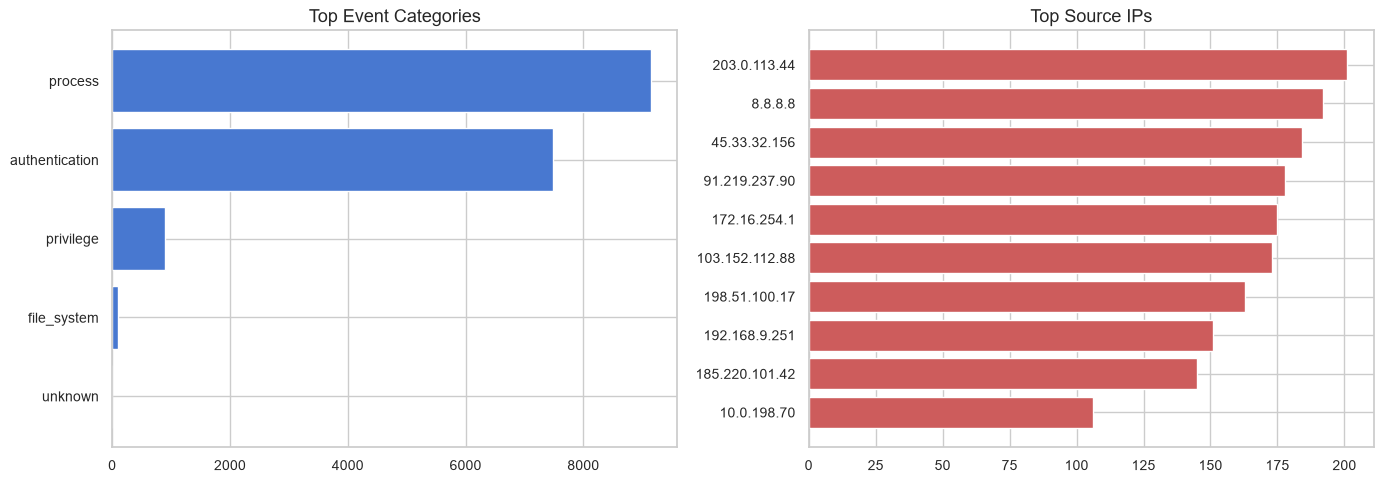

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat = df_events["category"].value_counts().head(10)
axes[0].barh(cat.index, cat.values)
axes[0].set_title("Top Event Categories")
axes[0].invert_yaxis()

ips = df_events["source_ip"].replace("", np.nan).dropna().value_counts().head(10)
axes[1].barh(ips.index, ips.values, color="indianred")
axes[1].set_title("Top Source IPs")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

---
## Section 5 — Feature Engineering

DefenSync builds features in `DetectionService._features()` (`backend/services/detection_service.py`).

| # | Feature | Source | Transformation |
|---|---------|--------|----------------|
| 0 | login_hour | timestamp or login_time | float hour 0–23 |
| 1 | session_duration | events.session_duration | NULL → 0 |
| 2 | failed_login_count | events.failed_login_count | NULL → 0 |
| 3 | cpu_usage | SSH `top` at collection | NULL → 0 |
| 4 | memory_usage | SSH `free` | NULL → 0 |
| 5 | disk_usage | SSH `df` | NULL → 0 |
| 6 | commands_executed | events.commands_executed | NULL → 0 |
| 7 | network_connections | SSH `ss` line count | NULL → 0 |
| 8 | risk_score | RiskEngine output | integer 0–100 |
| 9 | severity_encoded | severity string | info=0 … critical=4 |
| 10 | is_suspicious_type | event_type | 1 if in SUSPICIOUS_TYPES |
| 11 | is_failed_login | event_type | 1 if Failed Login |
| 12 | is_root_user | username | 1 if root |
| 13 | is_remote_ip | source_ip | 1 if non-empty and not 127.* |
| 14 | server_hash_feature | server_id | abs(hash(id))%1000/1000 |

**Encoding:** Manual numeric maps (no one-hot).  
**Scaling:** None in production — raw floats passed to sklearn.

In [7]:
# Load events exactly as DetectionService._load_events(limit=2000)
session = get_session()
try:
    events_orm = list(
        reversed(
            session.scalars(
                select(SecurityEvent).order_by(SecurityEvent.timestamp.desc()).limit(2000)
            ).all()
        )
    )
finally:
    session.close()

print(f"ML training window: {len(events_orm)} events (production limit=2000)")

FEATURE_NAMES = [
    "login_hour", "session_duration", "failed_login_count", "cpu_usage", "memory_usage",
    "disk_usage", "commands_executed", "network_connections", "risk_score", "severity_encoded",
    "is_suspicious_type", "is_failed_login", "is_root_user", "is_remote_ip", "server_hash_feature",
]

X = DetectionService._features(events_orm)
y_pseudo = DetectionService._labels(events_orm)

df_features = pd.DataFrame(X, columns=FEATURE_NAMES)
df_features["event_id"] = [e.event_id for e in events_orm]
print(f"Feature matrix shape: {X.shape}")
display(df_features.describe().T)
display(df_features.head())

ML training window: 2000 events (production limit=2000)
Feature matrix shape: (2000, 15)


,count,mean,std,min,25%,50%,75%,max
login_hour,2000.0,4.195500,8.866148,0.0,0.000,0.000,0.000,23.000
session_duration,2000.0,50.913000,927.652268,0.0,0.000,0.000,0.000,21714.400
failed_login_count,2000.0,0.024500,0.796377,0.0,0.000,0.000,0.000,34.000
cpu_usage,2000.0,0.152200,2.776662,0.0,0.000,0.000,0.000,83.800
memory_usage,2000.0,71.836145,4.525934,0.0,71.350,71.470,71.470,75.540
disk_usage,2000.0,27.982800,1.862917,0.0,28.000,28.000,28.000,66.700
commands_executed,2000.0,0.361500,10.682972,0.0,0.000,0.000,0.000,459.000
network_connections,2000.0,10.120500,4.197593,0.0,10.000,10.000,10.000,178.000
risk_score,2000.0,39.937000,3.393492,7.0,40.000,40.000,40.000,95.000
severity_encoded,2000.0,1.012500,0.165401,0.0,1.000,1.000,1.000,4.000


,login_hour,session_duration,failed_login_count,cpu_usage,memory_usage,disk_usage,commands_executed,network_connections,risk_score,severity_encoded,is_suspicious_type,is_failed_login,is_root_user,is_remote_ip,server_hash_feature,event_id
0,23.0,0.0,0.0,0.0,75.54,28.0,0.0,10.0,40.0,1.0,0.0,0.0,0.0,0.0,0.523,d9981317-639c-4be4-9cba-4b19f0e0b14b
1,23.0,0.0,0.0,0.0,75.54,28.0,0.0,10.0,40.0,1.0,0.0,0.0,0.0,0.0,0.523,3c7b8b2d-e94a-461f-8ac4-03084c0440b2
2,23.0,0.0,0.0,0.0,75.54,28.0,0.0,10.0,40.0,1.0,0.0,0.0,0.0,0.0,0.523,6f78193c-adb0-4962-a945-b7d1de6c7133
3,23.0,0.0,0.0,0.0,75.54,28.0,0.0,10.0,40.0,1.0,0.0,0.0,0.0,0.0,0.523,d7a0e995-fa1a-4b52-97fc-b5b5691a84bf
4,23.0,0.0,0.0,0.0,75.54,28.0,0.0,10.0,40.0,1.0,0.0,0.0,0.0,0.0,0.523,b9eb7445-7445-4a15-a880-552f81ccf542


---
## Section 6 — Isolation Forest

### Why Isolation Forest?

DefenSync uses **Isolation Forest** for **unsupervised** multivariate anomaly detection. Unlike signature-based rules, Isolation Forest identifies events that are **statistically isolated** in the 15-dimensional behavioral feature space — meaning they require fewer random splits to separate from the bulk of normal activity.

### How Isolation Forest Isolates Abnormal Behaviour

1. Random trees partition the feature space using random features and split values.
2. **Normal** events (dense regions) require many splits to isolate.
3. **Abnormal** events (sparse/outlier regions) are isolated in fewer splits.
4. Events with shorter average path length receive higher anomaly scores.
5. DefenSync flags events where `predict == -1` and stores `isolation_score = -score_samples()`.

### Production Parameters (`detection_service.py`)

| Parameter | Value |
|-----------|-------|
| `contamination` | `0.1` |
| `random_state` | `42` |
| `n_estimators` | `100` |

### Production Workflow

`fit(features)` → `predict == -1` → anomaly flag → `isolation_score = -score_samples(features)`


In [8]:
iso = IsolationForest(contamination=0.1, random_state=42, n_estimators=100)
iso.fit(X)
anomaly_flags = iso.predict(X) == -1
anomaly_scores = -iso.score_samples(X)

n_normal = int((~anomaly_flags).sum())
n_anomaly = int(anomaly_flags.sum())
anomaly_pct = (n_anomaly / len(X) * 100) if len(X) else 0.0

risk_ml = pd.Series([e.risk_score for e in events_orm])

if_summary = pd.DataFrame({
    "Metric": [
        "Total Events Analysed (ML window)",
        "Normal Count (IF predict != -1)",
        "Anomaly Count (IF predict == -1)",
        "Anomaly Percentage",
        "Isolation Score — Minimum",
        "Isolation Score — Maximum",
        "Isolation Score — Mean",
        "Isolation Score — Median",
        "Average Risk Score (ML window)",
        "Maximum Risk Score (ML window)",
        "Minimum Risk Score (ML window)",
    ],
    "Value": [
        len(X),
        n_normal,
        n_anomaly,
        f"{anomaly_pct:.2f}%",
        f"{anomaly_scores.min():.4f}",
        f"{anomaly_scores.max():.4f}",
        f"{anomaly_scores.mean():.4f}",
        f"{np.median(anomaly_scores):.4f}",
        f"{risk_ml.mean():.2f}",
        int(risk_ml.max()),
        int(risk_ml.min()),
    ],
})
display(if_summary.style.set_caption("Isolation Forest — Operational Summary (Live Data)").hide(axis="index"))

df_if = pd.DataFrame({
    "event_id": [e.event_id for e in events_orm],
    "is_anomaly": anomaly_flags,
    "isolation_score": anomaly_scores,
    "risk_score": risk_ml.values,
    "timestamp": [e.timestamp for e in events_orm],
})
print("\nTop 10 anomalies by isolation score:")
display(df_if[df_if["is_anomaly"]].sort_values("isolation_score", ascending=False).head(10))


Metric,Value
Total Events Analysed (ML window),2000
Normal Count (IF predict != -1),1961
Anomaly Count (IF predict == -1),39
Anomaly Percentage,1.95%
Isolation Score — Minimum,0.4144
Isolation Score — Maximum,0.7953
Isolation Score — Mean,0.4384
Isolation Score — Median,0.4153
Average Risk Score (ML window),39.94
Maximum Risk Score (ML window),95



Top 10 anomalies by isolation score:


,event_id,is_anomaly,isolation_score,risk_score,timestamp
1996,aece5308-ad1b-4af1-adf7-87d566ffb3ce,True,0.795298,30,2026-07-08 13:51:16.418126
1997,ee3db443-1870-47e6-ae32-3eddf1430f2f,True,0.761718,85,2026-07-08 13:51:16.418167
1998,b93689c6-1fb4-4e14-9944-779fb1c627b1,True,0.761433,10,2026-07-08 13:51:16.418173
353,3028cef3-a3f7-40bc-966b-5c3265734e4e,True,0.751680,23,2026-07-07 23:32:26.785310
1995,b9c5a857-7c9d-4226-9c4f-fc2e996610e2,True,0.744562,45,2026-07-08 13:51:11.972320
356,40647034-7641-4b0b-b57b-d279b733131c,True,0.728925,7,2026-07-07 23:41:53.400460
361,ec5bf8ce-61a1-4e86-8656-7a9cf7983ce0,True,0.723641,86,2026-07-07 23:54:36.164721
1999,1064d675-7b29-4d1f-bbfb-43eb8d8fc0b7,True,0.722485,95,2026-07-08 13:51:16.418176
355,5a31b2de-ab6f-409c-a10a-b2f541ef076b,True,0.720432,8,2026-07-07 23:37:01.357134
358,f4210366-18e2-49a5-b316-680b197206da,True,0.704897,69,2026-07-07 23:47:26.142311


---
## Section 7 — Isolation Forest Visualizations

The charts below visualize anomaly separation, score distribution, and temporal clustering using the **same 2,000-event ML window** loaded from PostgreSQL.


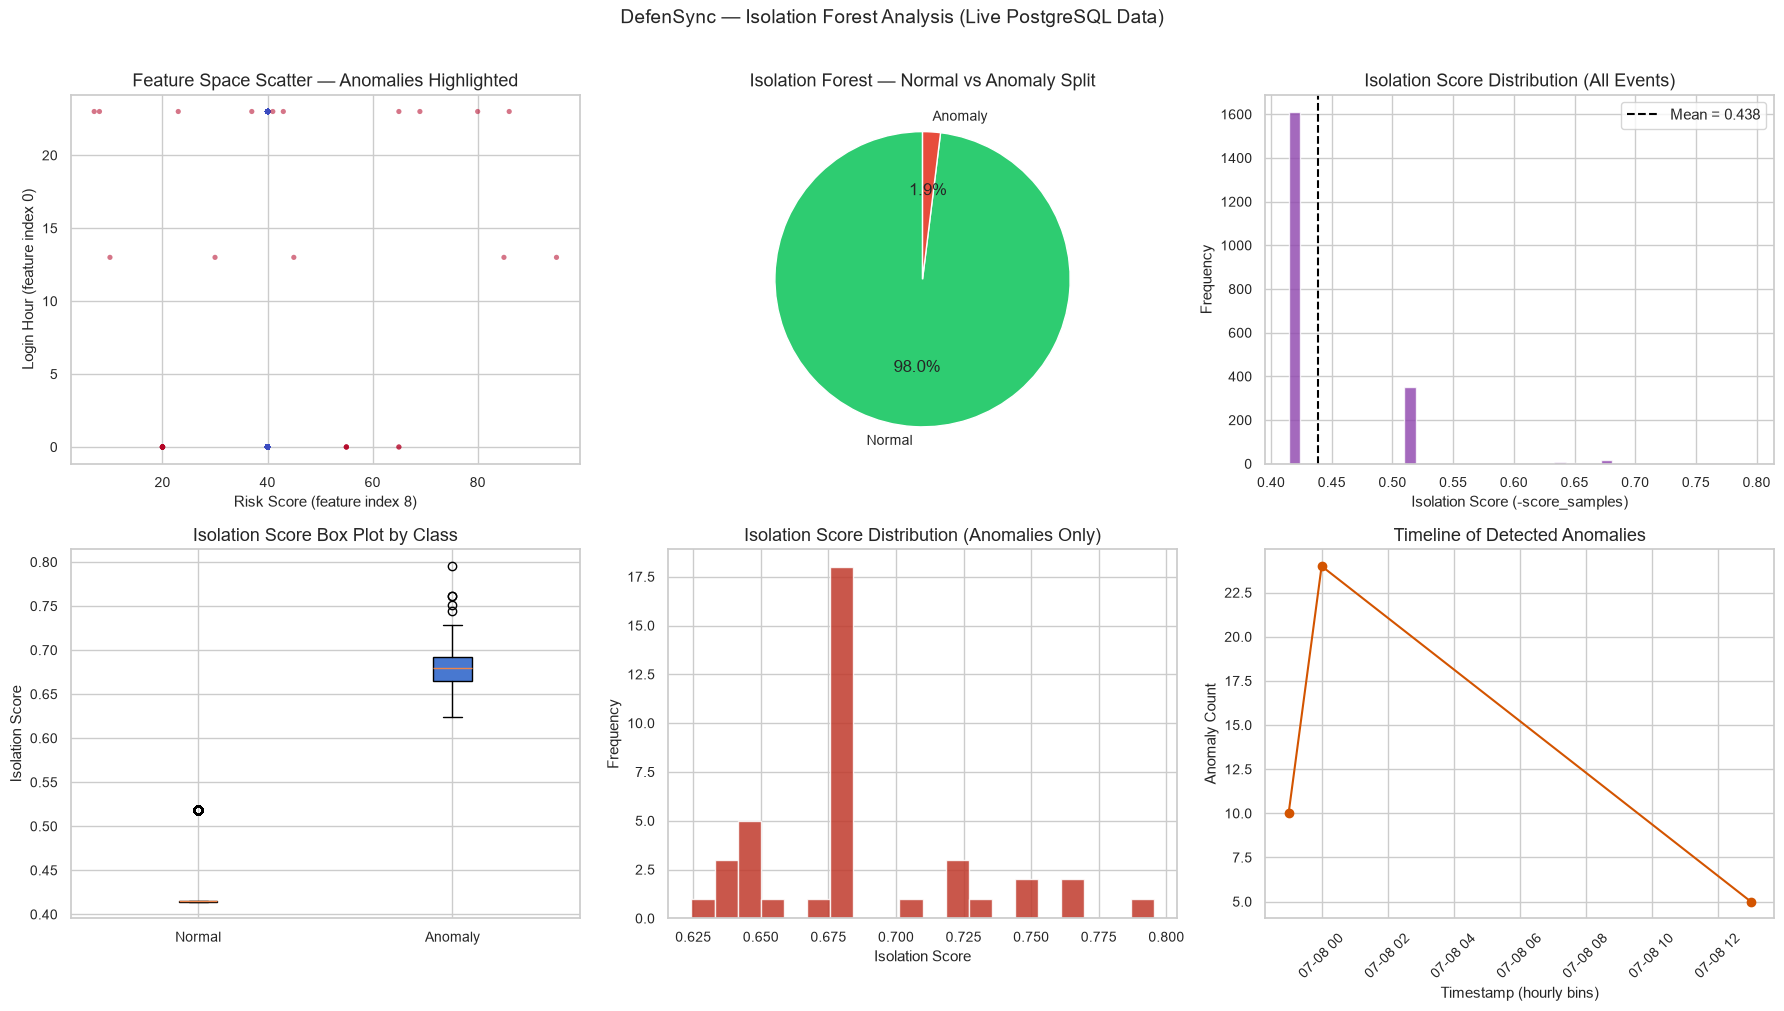

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Scatter plot
sc = axes[0, 0].scatter(
    X[:, 8], X[:, 0], c=anomaly_flags.astype(int), cmap="coolwarm", alpha=0.55, s=14, edgecolors="none"
)
axes[0, 0].set_xlabel("Risk Score (feature index 8)")
axes[0, 0].set_ylabel("Login Hour (feature index 0)")
axes[0, 0].set_title("Feature Space Scatter — Anomalies Highlighted")

# 2. Pie chart
axes[0, 1].pie(
    [n_normal, n_anomaly],
    labels=["Normal", "Anomaly"],
    autopct="%1.1f%%",
    colors=["#2ecc71", "#e74c3c"],
    startangle=90,
)
axes[0, 1].set_title("Isolation Forest — Normal vs Anomaly Split")

# 3. Histogram — all scores
axes[0, 2].hist(anomaly_scores, bins=40, color="#8e44ad", alpha=0.8, edgecolor="white")
axes[0, 2].axvline(anomaly_scores.mean(), color="black", linestyle="--", label=f"Mean = {anomaly_scores.mean():.3f}")
axes[0, 2].set_xlabel("Isolation Score (-score_samples)")
axes[0, 2].set_ylabel("Frequency")
axes[0, 2].set_title("Isolation Score Distribution (All Events)")
axes[0, 2].legend()

# 4. Box plot — normal vs anomaly scores
box_data = [anomaly_scores[~anomaly_flags], anomaly_scores[anomaly_flags]]
axes[1, 0].boxplot(box_data, tick_labels=["Normal", "Anomaly"], patch_artist=True)
axes[1, 0].set_ylabel("Isolation Score")
axes[1, 0].set_title("Isolation Score Box Plot by Class")

# 5. Histogram — anomalies only
if n_anomaly:
    axes[1, 1].hist(anomaly_scores[anomaly_flags], bins=min(20, n_anomaly), color="#c0392b", alpha=0.85, edgecolor="white")
else:
    axes[1, 1].text(0.5, 0.5, "No anomalies detected", ha="center", va="center")
axes[1, 1].set_xlabel("Isolation Score")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].set_title("Isolation Score Distribution (Anomalies Only)")

# 6. Timeline
df_if["ts"] = pd.to_datetime(df_if["timestamp"])
timeline = df_if[df_if["is_anomaly"]].groupby(df_if["ts"].dt.floor("h")).size()
axes[1, 2].plot(timeline.index, timeline.values, marker="o", color="#d35400")
axes[1, 2].set_xlabel("Timestamp (hourly bins)")
axes[1, 2].set_ylabel("Anomaly Count")
axes[1, 2].set_title("Timeline of Detected Anomalies")
axes[1, 2].tick_params(axis="x", rotation=45)

plt.suptitle("DefenSync — Isolation Forest Analysis (Live PostgreSQL Data)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


---
## Section 8 — Random Forest

**Labels** (`DetectionService._labels`):  
`1` (suspicious) if `risk_score >= 70` OR `event_type in SUSPICIOUS_TYPES`  
`SUSPICIOUS_TYPES = {Failed Login, Invalid User, User Creation, Sudo Command}`  
Else `0` (normal).

**Parameters:** `RandomForestClassifier(n_estimators=50, random_state=42, max_depth=6)`  
**Trained only if** `len(unique_labels) >= 2`

**Final classes** (merge logic in `run_detection`):
- **Malicious:** risk ≥ 85 OR (anomaly AND rf_suspicious)
- **Suspicious:** risk ≥ 70 OR anomaly OR rf_suspicious
- **Normal:** otherwise

In [10]:
unique_labels = len(set(y_pseudo.tolist()))
rf_suspicious = np.zeros(len(events_orm), dtype=bool)
rf_model = None

if unique_labels >= 2:
    rf_model = RandomForestClassifier(n_estimators=50, random_state=42, max_depth=6)
    rf_model.fit(X, y_pseudo)
    rf_suspicious = rf_model.predict(X) == 1
    print(f"Random Forest trained. Unique pseudo-labels: {unique_labels}")
else:
    print("Random Forest skipped — need >= 2 label classes (production behavior).")

classifications = []
detection_types = []
confidences = []

for idx, event in enumerate(events_orm):
    score = float(anomaly_scores[idx])
    is_anomaly = bool(anomaly_flags[idx])
    is_rf = bool(rf_suspicious[idx])

    if event.risk_score >= 85 or (is_anomaly and is_rf):
        cls = "Malicious"
    elif event.risk_score >= 70 or is_anomaly or is_rf:
        cls = "Suspicious"
    else:
        cls = "Normal"

    if is_anomaly and is_rf:
        dtype = "hybrid"
    elif is_anomaly:
        dtype = "isolation_forest"
    elif is_rf:
        dtype = "random_forest"
    elif event.risk_score >= 70:
        dtype = "rule_based"
    else:
        dtype = "normal"

    conf = round(min(0.99, max(0.5, score / (score + 1.0))), 3)
    classifications.append(cls)
    detection_types.append(dtype)
    confidences.append(conf)

df_pred = pd.DataFrame({
    "event_id": [e.event_id for e in events_orm],
    "classification": classifications,
    "detection_type": detection_types,
    "confidence": confidences,
    "random_forest_label": np.where(rf_suspicious, "suspicious", "normal"),
    "is_anomaly": anomaly_flags,
})

print("Classification distribution (this run, n=2000 window):")
print(df_pred["classification"].value_counts())
print("\nDetection type distribution:")
print(df_pred["detection_type"].value_counts())

Random Forest trained. Unique pseudo-labels: 2
Classification distribution (this run, n=2000 window):
classification
Normal        1961
Suspicious      29
Malicious       10
Name: count, dtype: int64

Detection type distribution:
detection_type
normal              1961
isolation_forest      29
hybrid                10
Name: count, dtype: int64


---
## Section 9 — Operational ML Outputs & Prediction Distribution

### Random Forest Label Context

> ⚠️ **Important — Operational Labels vs Ground Truth**
>
> Random Forest in DefenSync is trained using project-generated labels derived from risk score and event type. These labels are **operational labels** used by the detection pipeline rather than externally annotated ground-truth data. Therefore the evaluation shown in this notebook represents consistency with the project rules rather than real-world predictive accuracy.
>
> **Accuracy, Precision, Recall, F1 Score, and ROC Curve are not reported** because no externally verified attack labels exist in the database.

### Operational ML Outputs

The table below summarizes detection behaviour on the live PostgreSQL dataset using the production 2,000-event ML window and hybrid merge logic from `DetectionService.run_detection()`.

### Prediction Distribution Dashboard

Hybrid classification output (Normal / Suspicious / Malicious) for the current ML run.


In [11]:
n_normal_cls = int((df_pred["classification"] == "Normal").sum())
n_susp_cls = int((df_pred["classification"] == "Suspicious").sum())
n_mal_cls = int((df_pred["classification"] == "Malicious").sum())

operational = pd.DataFrame({
    "Operational Metric": [
        "Total Events Analysed (ML window)",
        "Total Normal Events (classification)",
        "Total Suspicious Events (classification)",
        "Total Malicious Events (classification)",
        "Total Isolation Forest Anomalies",
        "Percentage of Anomalies",
        "Average Risk Score (ML window)",
        "Maximum Risk Score (ML window)",
        "Minimum Risk Score (ML window)",
        "Total Events in Database (full table)",
        "Total Alerts in Database",
        "Total Detections Stored in Database",
    ],
    "Value": [
        len(events_orm),
        n_normal_cls,
        n_susp_cls,
        n_mal_cls,
        n_anomaly,
        f"{anomaly_pct:.2f}%",
        f"{risk_ml.mean():.2f}",
        int(risk_ml.max()),
        int(risk_ml.min()),
        len(df_events),
        len(df_alerts),
        len(df_detections),
    ],
})
display(operational.style.set_caption("DefenSync — Operational ML Outputs (Live PostgreSQL)").hide(axis="index"))

if rf_model is not None:
    rf_dist = pd.Series(rf_model.predict(X)).map({0: "normal", 1: "suspicious"}).value_counts()
    print("\nRandom Forest operational label distribution (0=normal, 1=suspicious):")
    display(rf_dist.to_frame("count"))
else:
    print("Random Forest was not trained (production requires >= 2 pseudo-label classes).")


Operational Metric,Value
Total Events Analysed (ML window),2000
Total Normal Events (classification),1961
Total Suspicious Events (classification),29
Total Malicious Events (classification),10
Total Isolation Forest Anomalies,39
Percentage of Anomalies,1.95%
Average Risk Score (ML window),39.94
Maximum Risk Score (ML window),95
Minimum Risk Score (ML window),7
Total Events in Database (full table),17622



Random Forest operational label distribution (0=normal, 1=suspicious):


,count
normal,1990
suspicious,10


Classification,Count,Percentage
Normal,1961,98.05%
Suspicious,29,1.45%
Malicious,10,0.5%


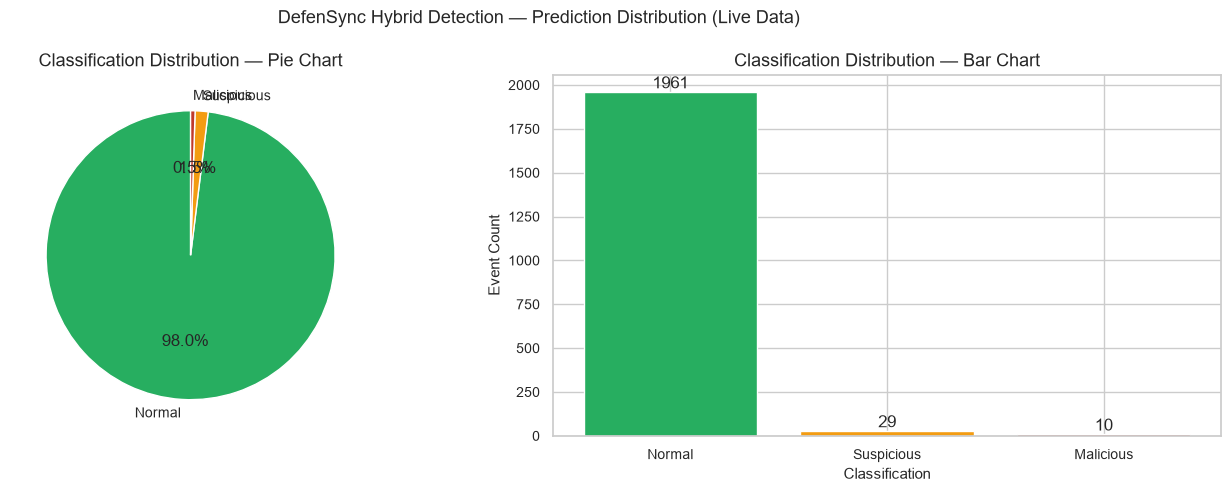

Stored detections table (production history) — classification counts:


,stored_count
classification,
Normal,7240
Suspicious,1379
Malicious,725


In [12]:
class_counts = df_pred["classification"].value_counts().reindex(["Normal", "Suspicious", "Malicious"], fill_value=0)
class_pct = (class_counts / class_counts.sum() * 100).round(2)

dist_table = pd.DataFrame({
    "Classification": class_counts.index,
    "Count": class_counts.values,
    "Percentage": class_pct.values.astype(str) + "%",
})
display(dist_table.style.set_caption("Hybrid Classification Distribution").hide(axis="index"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"Normal": "#27ae60", "Suspicious": "#f39c12", "Malicious": "#c0392b"}

axes[0].pie(class_counts.values, labels=class_counts.index, autopct="%1.1f%%",
            colors=[colors[c] for c in class_counts.index], startangle=90)
axes[0].set_title("Classification Distribution — Pie Chart")

bars = axes[1].bar(class_counts.index, class_counts.values, color=[colors[c] for c in class_counts.index])
axes[1].set_title("Classification Distribution — Bar Chart")
axes[1].set_xlabel("Classification")
axes[1].set_ylabel("Event Count")
for bar, val in zip(bars, class_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(val), ha="center", va="bottom")

plt.suptitle("DefenSync Hybrid Detection — Prediction Distribution (Live Data)", fontsize=13)
plt.tight_layout()
plt.show()

if len(df_detections):
    print("Stored detections table (production history) — classification counts:")
    display(df_detections["classification"].value_counts().to_frame("stored_count"))


---
## Section 10 — Feature Importance

Random Forest computes `feature_importances_` after training on operational pseudo-labels. DefenSync does **not** persist feature importance in the database; values are computed here for analysis using the same model configuration as production.

Feature importance indicates which behavioural dimensions contributed most to the Random Forest split decisions when learning operational suspicious vs normal patterns.


,rank,importance
risk_score,1,0.2470
is_suspicious_type,2,0.2281
memory_usage,3,0.0981
severity_encoded,4,0.0649
disk_usage,5,0.0647
is_failed_login,6,0.0634
server_hash_feature,7,0.0615
commands_executed,8,0.0447
network_connections,9,0.0422
cpu_usage,10,0.0320



Top 5 Most Influential Features:
  1. risk_score (0.2470) — Rule-engine composite score; strongest signal for suspicious operational labels.
  2. is_suspicious_type (0.2281) — Flag for SUSPICIOUS_TYPES (Failed Login, Invalid User, User Creation, Sudo Command).
  3. memory_usage (0.0981) — Memory utilisation at collection time.
  4. severity_encoded (0.0649) — Encoded severity (info→critical); correlates with event criticality.
  5. disk_usage (0.0647) — Disk utilisation at collection time.


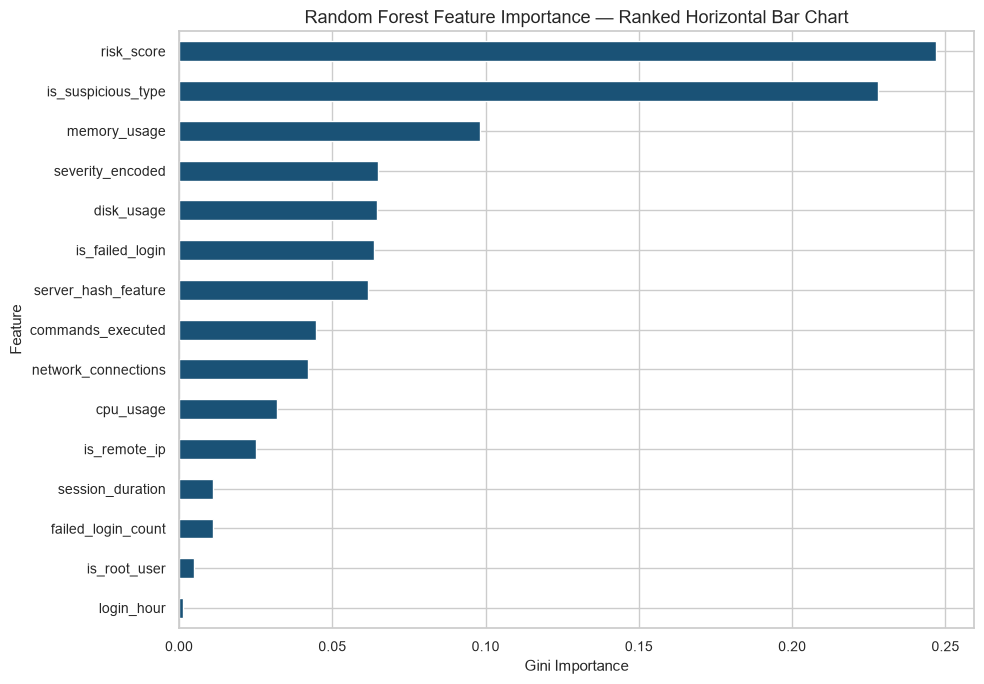

**Interpretation:** The top features reflect which behavioural dimensions the Random Forest relied on most when separating operational normal vs suspicious labels. In DefenSync, `risk_score` and severity-related features typically dominate because pseudo-labels are derived from the rule engine; telemetry features (CPU, session, network) capture multivariate behavioural context that complements rule-based scoring.

In [13]:
FEATURE_EXPLANATIONS = {
    "risk_score": "Rule-engine composite score; strongest signal for suspicious operational labels.",
    "severity_encoded": "Encoded severity (info→critical); correlates with event criticality.",
    "failed_login_count": "Behavioural brute-force indicator from auth telemetry.",
    "is_failed_login": "Binary flag for Failed Login event type.",
    "is_suspicious_type": "Flag for SUSPICIOUS_TYPES (Failed Login, Invalid User, User Creation, Sudo Command).",
    "login_hour": "Temporal behaviour — off-hours activity patterns.",
    "session_duration": "Session length from SSH-collected auth metadata.",
    "cpu_usage": "Server CPU at collection time (SSH `top`).",
    "memory_usage": "Memory utilisation at collection time.",
    "disk_usage": "Disk utilisation at collection time.",
    "commands_executed": "Command activity volume per session.",
    "network_connections": "Active network connections (`ss` count).",
    "is_root_user": "Privilege escalation / root activity indicator.",
    "is_remote_ip": "Remote source IP (non-localhost) indicator.",
    "server_hash_feature": "Server identity hash for per-server behavioural context.",
}

if rf_model is not None:
    imp = pd.Series(rf_model.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=False)
    imp_table = imp.to_frame("importance")
    imp_table["rank"] = range(1, len(imp_table) + 1)
    imp_table = imp_table[["rank", "importance"]]

    display(imp_table.style.set_caption("Ranked Feature Importance Table").format({"importance": "{:.4f}"}))

    top5 = imp.head(5)
    print("\nTop 5 Most Influential Features:")
    for rank, (feat, val) in enumerate(top5.items(), start=1):
        print(f"  {rank}. {feat} ({val:.4f}) — {FEATURE_EXPLANATIONS.get(feat, '')}")

    fig, ax = plt.subplots(figsize=(10, 7))
    imp.sort_values(ascending=True).plot(kind="barh", ax=ax, color="#1a5276")
    ax.set_xlabel("Gini Importance")
    ax.set_ylabel("Feature")
    ax.set_title("Random Forest Feature Importance — Ranked Horizontal Bar Chart")
    plt.tight_layout()
    plt.show()

    display(Markdown(
        "**Interpretation:** The top features reflect which behavioural dimensions the Random Forest "
        "relied on most when separating operational normal vs suspicious labels. "
        "In DefenSync, `risk_score` and severity-related features typically dominate because "
        "pseudo-labels are derived from the rule engine; telemetry features (CPU, session, network) "
        "capture multivariate behavioural context that complements rule-based scoring."
    ))
else:
    print("Feature importance unavailable — Random Forest was not trained.")


---
## Section 11 — Hybrid Detection Strategy & Pipeline

### Hybrid Detection Strategy

DefenSync uses a **four-stage hybrid pipeline** that combines unsupervised anomaly detection, rule-based risk scoring, supervised operational classification, and alert generation.

```
Stage 1: Isolation Forest (Unsupervised)
    ↓  Multivariate anomaly flags + isolation_score
Stage 2: Risk Score (Rule Engine)
    ↓  risk_score, severity, risk_level from DEFAULT_RULES
Stage 3: Random Forest Classification (Operational Labels)
    ↓  random_forest_label + merged Normal/Suspicious/Malicious
Stage 4: Alert Generation
    ↓  AlertService.sync_from_events + create_ml_alert → alerts table
```

#### Why Hybrid Detection?

| Technique Alone | Limitation | Hybrid Benefit |
|-----------------|------------|----------------|
| Rules only | Cannot detect novel multivariate outliers | Isolation Forest finds behavioural anomalies rules miss |
| Isolation Forest only | High false positives on benign outliers | Rules + RF provide operational context |
| Random Forest only | Requires labels; project uses operational pseudo-labels | IF adds unsupervised signal without ground truth |
| **Combined** | — | **Normal / Suspicious / Malicious tiers** with detection_type attribution (rule_based, isolation_forest, random_forest, hybrid) |

Combining **unsupervised anomaly detection** with **supervised operational classification** and **rule-based risk scoring** improves behavioural threat detection because each stage compensates for the weaknesses of the others.

---

### End-to-End Pipeline

```
Linux Server
    ↓ SSH (Paramiko)
SSH Collector (CollectorService + log_sources catalog)
    ↓ raw log lines + system metrics (top/free/df/ss)
Parser (backend/parser/engine.py)
    ↓ structured dicts
Normalizer (EventNormalizer)
    ↓ NormalizedSecurityEvent
RiskEngine + DEFAULT_RULES (backend/risk/)
    ↓ risk_score, severity, risk_level
Events Table (PostgreSQL)
    ↓ DetectionService._load_events(limit=2000)
Feature Engineering (_features → 15-dim matrix)
    ↓
Isolation Forest (contamination=0.1, n_estimators=100)
    ↓ anomaly flags + isolation_score
Random Forest (n_estimators=50, max_depth=6, pseudo-labels)
    ↓ random_forest_label + merged classification
Detections Table (detections / MLPrediction)
    ↓ AlertService.sync_from_events + create_ml_alert
Alerts Table
    ↓ Dashboard / Detection page / Admin Console
```


---
## Section 12 — Integration with DefenSync

### Backend files responsible for ML
| File | Role |
|------|------|
| `backend/services/detection_service.py` | Isolation Forest, Random Forest, feature matrix, classification merge |
| `backend/services/alert_service.py` | Rule alerts + ML anomaly alerts |
| `backend/risk/engine.py` | Rule-based risk scoring (pre-ML) |
| `backend/risk/rules.py` | Failed login, root login, sudo, etc. |
| `backend/services/pipeline_service.py` | Collect → parse → normalize → ingest |
| `backend/services/collector_service.py` | SSH telemetry (cpu, memory, disk, network) |
| `backend/services/scheduler_service.py` | Post-collection detection per owner |
| `backend/api/detection.py` | REST API for detection |

### Database tables
| Table | ML role |
|-------|--------|
| `events` | Training/inference input |
| `detections` | Stored predictions |
| `alerts` | Actionable outputs |

### Detection APIs
- `GET /api/v1/detection/status`
- `POST /api/v1/detection/run`
- `GET /api/v1/detection/anomalies`

### Alert APIs
- `GET /api/v1/alerts`
- `GET /api/v1/alerts/summary`
- `POST /api/v1/alerts/{id}/ack`

In [14]:
# Optional: invoke production DetectionService on live DB (same code path as POST /detection/run)
session = get_session()
try:
    svc = DetectionService(session)
    status = svc.status(owner_id=None)
    print("Production detection status (global):")
    for k, v in status.items():
        print(f"  {k}: {v}")
finally:
    session.close()

Production detection status (global):
  engine: DefenSync Hybrid Detection
  models: ['Isolation Forest', 'Random Forest', 'Rule Engine']
  events_in_db: 17622
  ready: True
  alerts: {'total': 3077, 'unacknowledged': 2698, 'rule_based': 58, 'ml_anomaly': 1390, 'critical': 717}


---
## Section 13 — Conclusion

The Machine Learning module successfully demonstrates **behavioural anomaly detection** using Isolation Forest followed by event classification using Random Forest. This notebook validates the production implementation of DefenSync using **live PostgreSQL data**.

Since Random Forest uses **project-defined operational labels** instead of externally annotated datasets, this notebook focuses on **detection behaviour, prediction distribution, feature importance, and anomaly analysis** rather than conventional supervised accuracy metrics.

### Summary

| Aspect | Implementation |
|--------|----------------|
| Features | 15 behavioural features from `DetectionService._features()` — no sklearn scaling |
| Isolation Forest | `IsolationForest(contamination=0.1, random_state=42, n_estimators=100)` |
| Random Forest | `RandomForestClassifier(n_estimators=50, random_state=42, max_depth=6)` |
| Labels | Operational pseudo-labels from risk score ≥ 70 and SUSPICIOUS_TYPES |
| Storage | Predictions → `detections` table; alerts → `alerts` table |

### Advantages of Hybrid Detection

1. Rules provide interpretable baseline risk and alert synchronisation  
2. Isolation Forest discovers multivariate behavioural outliers  
3. Random Forest aligns with suspicious operational patterns  
4. Merge logic produces actionable Normal / Suspicious / Malicious tiers  
5. Results are persisted and surfaced on the analyst dashboard

### Current Limitations (As Implemented)

1. ML window capped at **2,000** most recent events per run  
2. Models **retrained on each** `run_detection()` call — no persisted `.pkl`  
3. RF labels are operational pseudo-labels, not analyst-verified ground truth  
4. No production accuracy / F1 / ROC tracking  
5. NULL telemetry fields are coerced to 0 during feature engineering  
6. Feature importance is not stored in the database

### Future Improvements (Academic Discussion Only)

Externally annotated datasets, model persistence, held-out evaluation, class imbalance handling, and SHAP explainability — none of these are implemented in the current codebase.


In [15]:
run_summary = pd.DataFrame({
    "Metric": [
        "Total Events (full PostgreSQL table)",
        "Events Analysed (ML window)",
        "Normal Events",
        "Suspicious Events",
        "Malicious Events",
        "Isolation Forest Anomalies",
        "Anomaly Percentage",
        "Features Used",
    ],
    "Value": [
        len(df_events),
        len(events_orm),
        n_normal_cls,
        n_susp_cls,
        n_mal_cls,
        n_anomaly,
        f"{anomaly_pct:.2f}%",
        X.shape[1],
    ],
})
display(run_summary.style.set_caption("ML Run Summary — Live Data").hide(axis="index"))


Metric,Value
Total Events (full PostgreSQL table),17622
Events Analysed (ML window),2000
Normal Events,1961
Suspicious Events,29
Malicious Events,10
Isolation Forest Anomalies,39
Anomaly Percentage,1.95%
Features Used,15


---
## Section 14 — Key Findings

This section consolidates the principal outcomes of the DefenSync ML analysis notebook for MCA project review and viva.


In [16]:
key_findings = pd.DataFrame({
    "Category": [
        "Total Events Processed",
        "Total Alerts Generated",
        "Total Detections Stored",
        "Number of Servers",
        "Number of Features Used",
        "Isolation Forest — contamination",
        "Isolation Forest — n_estimators",
        "Isolation Forest — random_state",
        "Random Forest — n_estimators",
        "Random Forest — max_depth",
        "Random Forest — random_state",
    ],
    "Value": [
        len(df_events),
        len(df_alerts),
        len(df_detections),
        len(df_servers),
        len(FEATURE_NAMES),
        0.1,
        100,
        42,
        50,
        6,
        42,
    ],
})
display(key_findings.style.set_caption("Key Findings — Live Database Statistics").hide(axis="index"))


Category,Value
Total Events Processed,17622.000000
Total Alerts Generated,3077.000000
Total Detections Stored,9344.000000
Number of Servers,2.000000
Number of Features Used,15.000000
Isolation Forest — contamination,0.100000
Isolation Forest — n_estimators,100.000000
Isolation Forest — random_state,42.000000
Random Forest — n_estimators,50.000000
Random Forest — max_depth,6.000000


### Files Responsible for ML

| File | Role |
|------|------|
| `backend/services/detection_service.py` | Isolation Forest, Random Forest, features, classification merge |
| `backend/services/alert_service.py` | Rule alerts + ML anomaly alerts |
| `backend/risk/engine.py` | Rule-based risk scoring |
| `backend/risk/rules.py` | Detection rules |
| `backend/services/pipeline_service.py` | Collect, parse, normalize, ingest |
| `backend/services/collector_service.py` | SSH telemetry collection |
| `backend/services/scheduler_service.py` | Scheduled detection per owner |
| `backend/api/detection.py` | Detection REST API |

### Database Tables Used

| Table | Purpose |
|-------|---------|
| `events` | ML input features and risk scores |
| `detections` | Stored ML predictions |
| `alerts` | Actionable security alerts |
| `servers` | Server metadata and health |

### APIs Used

| Endpoint | Purpose |
|----------|---------|
| `GET /api/v1/detection/status` | Detection engine status |
| `POST /api/v1/detection/run` | Trigger hybrid detection |
| `GET /api/v1/detection/anomalies` | Retrieve flagged events |
| `GET /api/v1/alerts` | List alerts |
| `GET /api/v1/alerts/summary` | Alert summary statistics |

### Advantages of the Hybrid ML Pipeline

1. **Unsupervised + supervised + rules** — complementary detection layers
2. **Behavioural features** — session, telemetry, auth, and temporal signals
3. **Live PostgreSQL integration** — no CSV or synthetic datasets
4. **Production parity** — notebook reuses `DetectionService._features()` and merge logic
5. **Actionable output** — classifications persisted to `detections` and `alerts`
